In [1]:
import praw
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import yfinance as yf

ImportError: 

IMPORTANT: PLEASE READ THIS FOR ADVICE ON HOW TO SOLVE THIS ISSUE!

Importing the numpy C-extensions failed. This error can happen for
many reasons, often due to issues with your setup or how NumPy was
installed.

We have compiled some common reasons and troubleshooting tips at:

    https://numpy.org/devdocs/user/troubleshooting-importerror.html

Please note and check the following:

  * The Python version is: Python3.9 from "C:\Users\91939\anaconda3\python.exe"
  * The NumPy version is: "1.21.5"

and make sure that they are the versions you expect.
Please carefully study the documentation linked above for further help.

Original error was: DLL load failed while importing _multiarray_umath: The specified module could not be found.


ImportError: 

IMPORTANT: PLEASE READ THIS FOR ADVICE ON HOW TO SOLVE THIS ISSUE!

Importing the numpy C-extensions failed. This error can happen for
many reasons, often due to issues with your setup or how NumPy was
installed.

We have compiled some common reasons and troubleshooting tips at:

    https://numpy.org/devdocs/user/troubleshooting-importerror.html

Please note and check the following:

  * The Python version is: Python3.9 from "C:\Users\91939\anaconda3\python.exe"
  * The NumPy version is: "1.21.5"

and make sure that they are the versions you expect.
Please carefully study the documentation linked above for further help.

Original error was: DLL load failed while importing _multiarray_umath: The specified module could not be found.


ImportError: 

IMPORTANT: PLEASE READ THIS FOR ADVICE ON HOW TO SOLVE THIS ISSUE!

Importing the numpy C-extensions failed. This error can happen for
many reasons, often due to issues with your setup or how NumPy was
installed.

We have compiled some common reasons and troubleshooting tips at:

    https://numpy.org/devdocs/user/troubleshooting-importerror.html

Please note and check the following:

  * The Python version is: Python3.9 from "C:\Users\91939\anaconda3\python.exe"
  * The NumPy version is: "1.21.5"

and make sure that they are the versions you expect.
Please carefully study the documentation linked above for further help.

Original error was: DLL load failed while importing _multiarray_umath: The specified module could not be found.


ImportError: _multiarray_umath failed to import

ImportError: numpy._core.umath failed to import

In [9]:
# Reddit API Setup
reddit = praw.Reddit(client_id="61G5r3qum5peFaRdvtbMJg",
    client_secret="yPzjWBhh797nj2muWQJt3jAEhtZtqg",
    user_agent="script by u/Educational_Leek_918")

def scrape_reddit(subreddit_name, num_posts=500):
    subreddit = reddit.subreddit(subreddit_name)
    posts = []
    for post in subreddit.hot(limit=num_posts):
        posts.append({
            'title': post.title,
            'selftext': post.selftext,
            'created': pd.to_datetime(post.created_utc, unit='s'),
            'upvotes': post.ups,
            'downvotes': post.downs,
            'comments': post.num_comments,
            'url': post.url
        })
    return pd.DataFrame(posts)

reddit_data = scrape_reddit('stocks', 500)  # Scrape top 200 posts from r/stocks

In [10]:
# Sentiment Analysis using Hugging Face Transformers (DistilBERT model)
sentiment_pipeline = pipeline('sentiment-analysis', model="distilbert-base-uncased-finetuned-sst-2-english")

def llm_sentiment_analysis(data):
    data['sentiment'] = data['title'].apply(lambda x: sentiment_pipeline(x)[0]['label'])
    data['sentiment_score'] = data['title'].apply(lambda x: sentiment_pipeline(x)[0]['score'])
    data['sentiment_numeric'] = data['sentiment'].apply(lambda x: 1 if x == 'POSITIVE' else -1)
    return data

reddit_data = llm_sentiment_analysis(reddit_data)

In [11]:
import re

def extract_numerical_data(text):
    # Regular expression to capture stock prices or any numerical data
    numbers = re.findall(r'\b\d+\.\d+\b|\b\d+\b', text)
    return [float(num) for num in numbers]

reddit_data['numerical_data'] = reddit_data['selftext'].apply(lambda x: extract_numerical_data(x))
reddit_data['numerical_data'] = reddit_data['numerical_data'].apply(lambda x: np.mean(x) if len(x) > 0 else np.nan)

In [12]:
# Extracting relevant features like upvotes, downvotes, number of comments, sentiment score, and numerical data
def feature_engineering(data):
    data['hour'] = data['created'].dt.hour
    data['day_of_week'] = data['created'].dt.dayofweek
    data['num_words'] = data['selftext'].apply(lambda x: len(x.split()))
    return data

reddit_data = feature_engineering(reddit_data)
reddit_data.dropna(subset=['numerical_data'], inplace=True)  # Drop rows without numerical data

In [13]:
# Scaling the features
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(reddit_data[['upvotes', 'downvotes', 'comments', 'sentiment_score', 'numerical_data', 'num_words']])
scaled_data = pd.DataFrame(scaled_features, columns=['upvotes', 'downvotes', 'comments', 'sentiment_score', 'numerical_data', 'num_words'])

In [14]:
def prepare_sequences(data, sequence_length=10):
    X, y = [], []
    for i in range(len(data) - sequence_length - 1):
        X.append(data[i:i + sequence_length])
        y.append(data[i + sequence_length, 0])  # Predicting the first column (upvotes or any numeric target)
    return np.array(X), np.array(y)

sequence_length = 10
X, y = prepare_sequences(scaled_data.values, sequence_length)

# Train-Test Split
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [15]:
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))



Epoch 1/20

5/5 [==============================] - 7s 289ms/step - loss: 0.0084 - val_loss: 5.1286e-04
Epoch 2/20
5/5 [==============================] - 0s 18ms/step - loss: 0.0086 - val_loss: 7.3364e-04
Epoch 3/20
5/5 [==============================] - 0s 21ms/step - loss: 0.0079 - val_loss: 5.8634e-04
Epoch 4/20
5/5 [==============================] - 0s 31ms/step - loss: 0.0083 - val_loss: 5.1171e-04
Epoch 5/20
5/5 [==============================] - 0s 19ms/step - loss: 0.0077 - val_loss: 7.7414e-04
Epoch 6/20
5/5 [==============================] - 0s 21ms/step - loss: 0.0082 - val_loss: 5.1823e-04
Epoch 7/20
5/5 [==============================] - 0s 20ms/step - loss: 0.0079 - val_loss: 0.0023
Epoch 8/20
5/5 [==============================] - 0s 30ms/step - loss: 0.0093 - val_loss: 0.0011
Epoch 9/20
5/5 [==============================] - 0s 31ms/step - loss: 0.0084 - val_loss: 5.3362e-04
Epoch 10/20
5/5 [==============================] - 0s 31ms/step - loss: 0.0080 - val_loss: 7.36

2/2 [==============================] - 1s 6ms/step


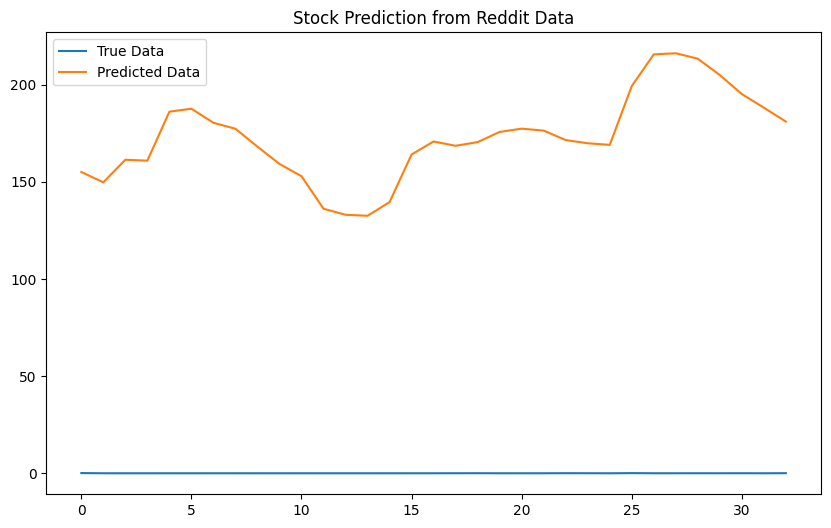

In [16]:
predicted_data = model.predict(X_test)
predicted_data = scaler.inverse_transform(np.concatenate((predicted_data, np.zeros((predicted_data.shape[0], 5))), axis=1))[:, 0]

# Visualizing the predictions
plt.figure(figsize=(10, 6))
plt.plot(np.arange(len(y_test)), y_test, label="True Data")
plt.plot(np.arange(len(predicted_data)), predicted_data, label="Predicted Data")
plt.title('Stock Prediction from Reddit Data')
plt.legend()
plt.show()

In [17]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test, predicted_data))
print(f"Root Mean Squared Error: {rmse}")

# If classification (e.g., increase/decrease prediction) is needed:
y_test_class = (y_test > 0).astype(int)
predicted_class = (predicted_data > 0).astype(int)

print(classification_report(y_test_class, predicted_class))

Root Mean Squared Error: 174.3866450108218
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.91      1.00      0.95        30

    accuracy                           0.91        33
   macro avg       0.45      0.50      0.48        33
weighted avg       0.83      0.91      0.87        33



C:\Users\vardh\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\vardh\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\vardh\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

* Explanation of Features:
    * Sentiment Analysis: The sentiment of Reddit posts (positive or negative) is used as a feature.
    * Numerical Data Extraction: Any numerical data from the post text is extracted (like stock prices or mentions of financial figures).
    * Engagement Metrics: Features such as upvotes, downvotes, comments, and the number of words in the post are used.
    * Date/Time Features: The hour and day of the week features are included to capture temporal patterns in stock discussions.
* Key Innovations:
    * LLM Sentiment Analysis: Advanced sentiment analysis with Hugging Face models.
    * Numerical Data Extraction: Extraction of real-world financial data directly from Reddit posts.
    * LSTM for Temporal Prediction: LSTM used to predict stock movements based on time-sequenced data.
    * Comprehensive Feature Set: Various features like sentiment score, engagement metrics, and numerical data for richer model inputs.

This approach should provide a robust model capable of making predictions based on the latest relevant discussions and trends.